In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

# Data Ingest

From the raw .Spe file collect:
* The recording time
* The real time
* The live time
* The spectrum of data 

In [3]:
# The lines of interest in the .Spe data file (starting from 0)
start_time_line = 7
measurement_time_line = 9
data_start_line = 12
data_end_line = 12 + 1023


def get_data(path):
    in_file = open(path, "r")

    lines = in_file.readlines()

    start = lines[start_time_line].strip().split(" ")
    start_date, start_time = start[0], start[1]

    measurement_time = lines[measurement_time_line].strip().split(" ")
    real_time, live_time = measurement_time[0], measurement_time[1]

    data = lines[data_start_line:data_end_line]

    data_dict = {
        "start_date": start_date,
        "start_time": start_time,
        "live_time": live_time,
        "real_time": real_time,
        "data": [int(x.strip()) for x in data]
    }

    in_file.close()

    return data_dict


In [4]:
background_dict = get_data(r"C:\pyt\ADV-Lab\nuetron-activation\data\BackgroundSample.Spe")
cs137_dict = get_data(r"C:\pyt\ADV-Lab\nuetron-activation\data\Cs137Cal.Spe")

# Spectrum CSV

In [5]:
def write_csv(data_dict, output_path):
    channels = np.arange(1, 1024).tolist()
    df = pd.DataFrame({"Channel": channels, "Counts": data_dict["data"]})
    df.to_csv(output_path, index=False)

In [6]:
write_csv(background_dict, r"C:\pyt\ADV-Lab\nuetron-activation\data\BackgroundSample.csv")

# Spectrum Plot

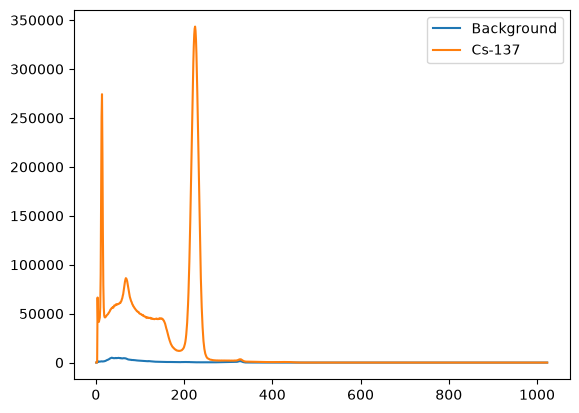

In [7]:
background_data = background_dict["data"]
cs137_data = cs137_dict["data"]
channels = np.arange(1, 1024)

plt.plot(channels, background_data, label="Background")
plt.plot(channels, cs137_data, label="Cs-137")
plt.legend()

# Subtracting Background

In [8]:
def sub_background_linear(sample_dict, background_dict):
    """assumes the background grows at a linear rate"""

    # multiply the background spectrum by the ratio of the sample and background live times
    sample_live_time = float(sample_dict["live_time"])
    background_live_time = float(background_dict["live_time"])

    ratio = sample_live_time / background_live_time

    background_data = np.array(background_dict["data"])
    scaled_background = background_data * ratio

    # subtract the scaled background from the sample data
    sample_data = np.array(sample_dict["data"])

    subtracted_data = sample_data - scaled_background

    return subtracted_data


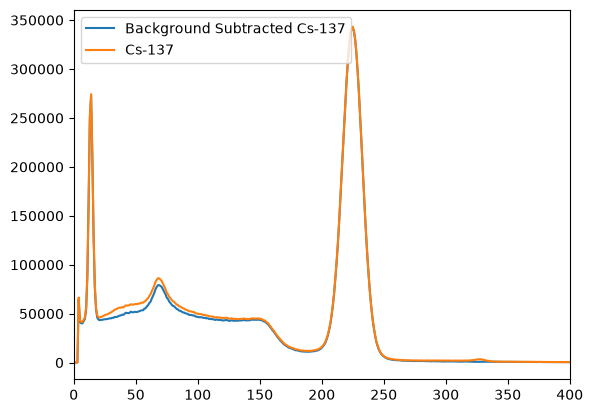

In [9]:
background_subtracted_data = sub_background_linear(cs137_dict, background_dict)

plt.plot(channels, background_subtracted_data, label="Background Subtracted Cs-137")
plt.plot(channels, cs137_dict["data"], label="Cs-137")
plt.xlim(0, 400)
plt.legend()


# Fitting gaussian

In [16]:
def gaussian(x, a, x0, sigma):
    """Gaussian function"""
    return a * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

def fit_gaussian(data, start_channel, end_channel):
    """Fit a Gaussian to the data between start_channel and end_channel"""

    # Get the data in the range
    x_data = np.arange(start_channel, end_channel + 1)
    y_data = data[start_channel - 1:end_channel]

    # Initial guess for the parameters
    initial_guess = [max(y_data), (start_channel + end_channel) / 2, (end_channel - start_channel) / 4]

    # Fit the Gaussian
    popt, pcov = opt.curve_fit(gaussian, x_data, y_data, p0=initial_guess)

    fit_a, fit_x0, fit_sigma = popt

    fit_y_data = gaussian(np.arange(start_channel, end_channel), fit_a, fit_x0, fit_sigma)

    return fit_y_data, fit_x0, fit_sigma

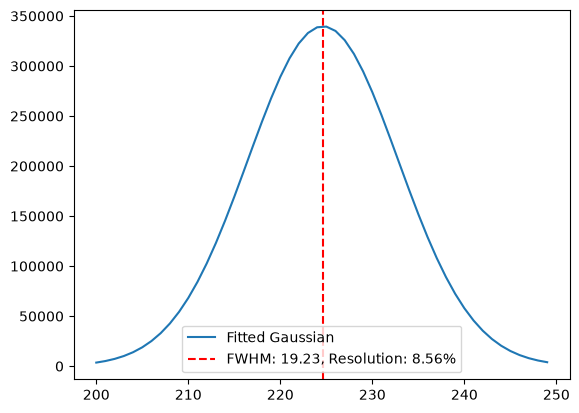

In [18]:
peak_channels = [200, 250]

fit_y_data, fit_x0, fit_sigma = fit_gaussian(background_subtracted_data, peak_channels[0], peak_channels[1])

plt.plot(np.arange(peak_channels[0], peak_channels[1]), fit_y_data, label="Fitted Gaussian")

fwhm = 2 * np.sqrt(2 * np.log(2)) * fit_sigma 
res = fwhm / fit_x0 * 100
plt.axvline(fit_x0, color='red', linestyle='--', label=f'FWHM: {fwhm:.2f}, Resolution: {res:.2f}%')
plt.legend()
